In [14]:
!pip install xlrd openpyxl

C:\Users\hitos\AppData\Local\Temp\ipykernel_11548\579341889.py:97: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(CODES_CONF, np.nan)


✅ Nettoyage terminé, fichiers CSV et graphiques générés.


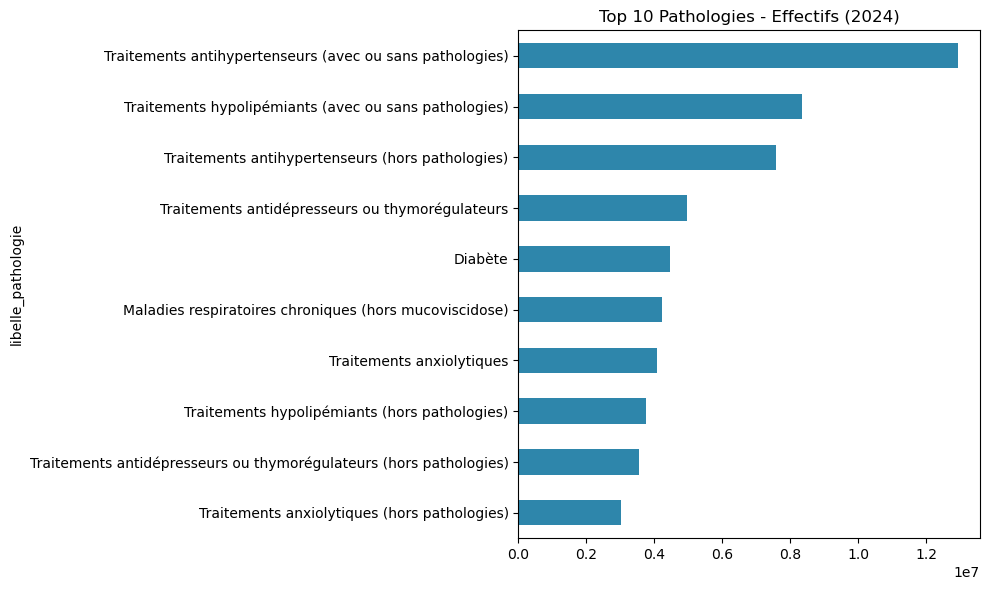

In [22]:
"""
Pipeline Data Quality & Analyse — Cartographie CNAM (2015-2024)
Projet 2 en santé de HUYNH PHILIPPE en master 2 Data science à Paris Saclay
"""
import glob
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Options pour éviter que le tableau soit "hors du cadre" dans la console
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

os.makedirs("images", exist_ok=True)
EFFECTIFS_DIR, DEPENSES_DIR = "data_effectifs", "data_depenses"
CODES_CONF = ["NS", "ns", "<50", "-", "N/A", ""]

def est_feuille_a_ignorer(nom):
    return any(m in nom.lower() for m in ["lisez", "sommaire", "présentation", "readme", "méthode"])

def detecter_ligne_entete(brut):
    for i, row in brut.iterrows():
        if (row.astype(str).str.strip().str.lower() == "top").any():
            return i
    return None

def charger_feuille(fichier, feuille):
    brut = pd.read_excel(fichier, sheet_name=feuille, header=None, nrows=15)
    i_entete = detecter_ligne_entete(brut)
    if i_entete is None: return None
    
    df = pd.read_excel(fichier, sheet_name=feuille, header=i_entete)
    df.columns = [str(c).strip() for c in df.columns]
    
    cols = list(df.columns)
    try:
        idx_top = [c.lower() for c in cols].index("top")
        cols[idx_top] = "code_pathologie"
        if idx_top - 1 >= 0: cols[idx_top - 1] = "libelle_pathologie"
        df.columns = cols
    except ValueError: pass
    return df

# 1. CHARGEMENT EFFECTIFS
dfs_eff = []
for f in sorted(glob.glob(os.path.join(EFFECTIFS_DIR, "*.xls*"))):
    annee = int(re.search(r"(20\d{2})", os.path.basename(f)).group(1))
    for feuille in pd.ExcelFile(f).sheet_names:
        if not est_feuille_a_ignorer(feuille):
            df = charger_feuille(f, feuille)
            if df is not None and "code_pathologie" in df.columns:
                df["annee"], df["region"] = annee, feuille
                dfs_eff.append(df)
df_effectifs = pd.concat(dfs_eff, ignore_index=True)

# 2. CHARGEMENT DÉPENSES
def detecter_ligne_entete_depenses(brut):
    for i, row in brut.iterrows():
        texte = " ".join(row.astype(str).str.strip().str.lower())
        # Prise en compte des accents ("é") pour détecter la ligne à coup sûr
        if "pathologie" in texte and ("depense" in texte or "dépense" in texte or "montant" in texte or "remboursement" in texte):
            return i
    return None

dfs_dep = []
for f in sorted(glob.glob(os.path.join(DEPENSES_DIR, "*.xls*"))):
    annee = int(re.search(r"(20\d{2})", os.path.basename(f)).group(1))
    xls = pd.ExcelFile(f)
    feuilles_utiles = [s for s in xls.sheet_names if not est_feuille_a_ignorer(s)]
    
    for feuille in feuilles_utiles:
        brut = pd.read_excel(f, sheet_name=feuille, header=None, nrows=40)
        i_entete = detecter_ligne_entete_depenses(brut)
        
        if i_entete is not None:
            df = pd.read_excel(f, sheet_name=feuille, header=i_entete)
            df.columns = [str(c).strip() for c in df.columns]
            
            # Renommage automatique
            for col in df.columns:
                if "pathologie" in col.lower() or "libell" in col.lower():
                    df.rename(columns={col: "code_pathologie"}, inplace=True)
                    break
                    
            df["annee"] = annee
            dfs_dep.append(df)
            break

df_depenses = pd.concat(dfs_dep, ignore_index=True) if dfs_dep else pd.DataFrame()

# 3. NETTOYAGE & TYPAGE
def nettoyer_numerique(df, colonnes):
    if df.empty: 
        return df
    df = df.replace(CODES_CONF, np.nan)
    for col in colonnes:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".").str.replace(" ", "").str.replace("\xa0", ""), errors="coerce")
    return df

cols_eff = [c for c in df_effectifs.columns if c.startswith("effectif_")]
cols_dep = [c for c in df_depenses.columns if "montant" in c.lower() or "dépense" in c.lower() or "depense" in c.lower()]

df_effectifs = nettoyer_numerique(df_effectifs, cols_eff)
df_depenses = nettoyer_numerique(df_depenses, cols_dep)

# Exclusion de la ligne technique pour les effectifs
masque = df_effectifs["libelle_pathologie"].str.lower().isin(["total (dénominateur)", "aucune pathologie", "pas de pathologie"])
df_effectifs_clean = df_effectifs[~masque].dropna(subset=["code_pathologie"])

# CORRECTION DU KEYERROR : Sécurisation du nettoyage des dépenses
if not df_depenses.empty and "code_pathologie" in df_depenses.columns:
    df_depenses_clean = df_depenses.dropna(subset=["code_pathologie"])
else:
    print("⚠️ Les données de dépenses n'ont pas pu être extraites ou la colonne est introuvable.")
    df_depenses_clean = pd.DataFrame()

# 4. ANALYSE ET EXPORT
annee_max = df_effectifs_clean["annee"].max()
top_eff = df_effectifs_clean[df_effectifs_clean["annee"] == annee_max].groupby("libelle_pathologie")["effectif_tot"].sum().sort_values(ascending=False).head(10)
top_eff.sort_values().plot(kind="barh", color="#2E86AB", figsize=(10,6), title=f"Top 10 Pathologies - Effectifs ({annee_max})")
plt.tight_layout(); plt.savefig("images/top10_effectifs.png")

df_effectifs_clean.to_csv("data_effectifs_clean.csv", index=False, encoding="utf-8-sig")
df_depenses_clean.to_csv("data_depenses_clean.csv", index=False, encoding="utf-8-sig")
print("✅ Nettoyage terminé, fichiers CSV et graphiques générés.")